In [1]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


Using device: cuda
Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train: 22968 | Val: 5741 | Test: 7179
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


🔒 STN frozen for first 10 epochs
🆕 Starting fresh training

🚀 Training: ResNet50 + STN + CBAM  (50 epochs, no early stopping)
   STN unfreezes at epoch 10 | MixUp ends at epoch 20
Epoch 1/50 🔒 | Loss: 1360.90 | Val Acc: 51.96% | LR: 0.000100
  ✅ New best saved: 51.96%
Epoch 2/50 🔒 | Loss: 1213.53 | Val Acc: 57.46% | LR: 0.000100
  ✅ New best saved: 57.46%
Epoch 3/50 🔒 | Loss: 1167.14 | Val Acc: 58.46% | LR: 0.000099
  ✅ New best saved: 58.46%
Epoch 4/50 🔒 | Loss: 1144.22 | Val Acc: 62.03% | LR: 0.000098
  ✅ New best saved: 62.03%
Epoch 5/50 🔒 | Loss: 1120.87 | Val Acc: 62.93% | LR: 0.000098
  ✅ New best saved: 62.93%
Epoch 6/50 🔒 | Loss: 1089.43 | Val Acc: 64.07% | LR: 0.000096
  ✅ New best saved: 64.07%
Epoch 7/50 🔒 | Loss: 1075.31 | Val Acc: 65.23% | LR: 0.000095
  ✅ New best saved: 65.23%
Epoch 8/50 🔒 | Loss: 1063.64 | Val Acc: 62.58% | LR: 0.000094
Epoch 9/50 🔒 | Loss: 1044.11 | Val Acc: 63.07% | LR: 0.000092
Epoch 10/50 🔒 | Loss: 1034.89 | Val Acc: 64.68% | LR: 0.000090

🔓 Epoch 1

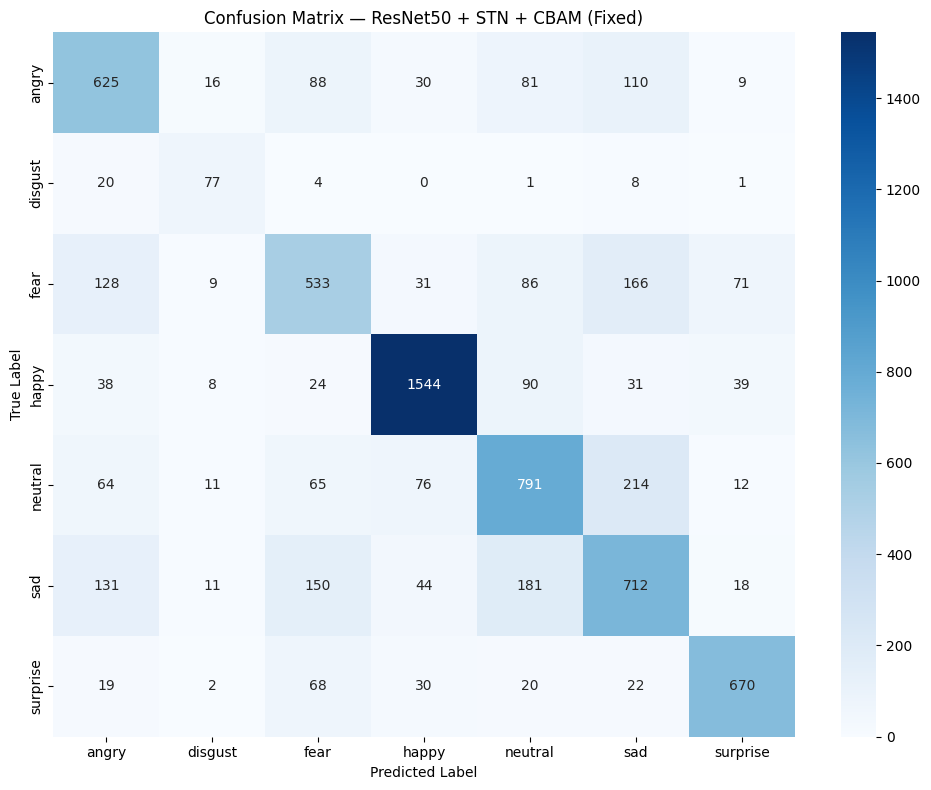


                  📊 FINAL MODEL COMPARISON
Model                                        Accuracy  F1 Weighted   F1 Macro
----------------------------------------------------------------------
1. Baseline ResNet50                           63.83%       63.74%      59.63%
2. Label Smoothing                             65.29%       65.25%      60.77%
3. ResNet50 + CBAM                             65.93%       65.88%      60.63%
4. ResNet50 + STN + CBAM (orig)                66.11%       66.33%      61.80%
4. ResNet50 + STN + CBAM (+50ep)               68.98%       68.98%      67.07%
5. EmoNeXt (ConvNeXt)                          64.03%       63.22%      58.82%

🏆 Best Model: 4. ResNet50 + STN + CBAM (+50ep) → 68.98%


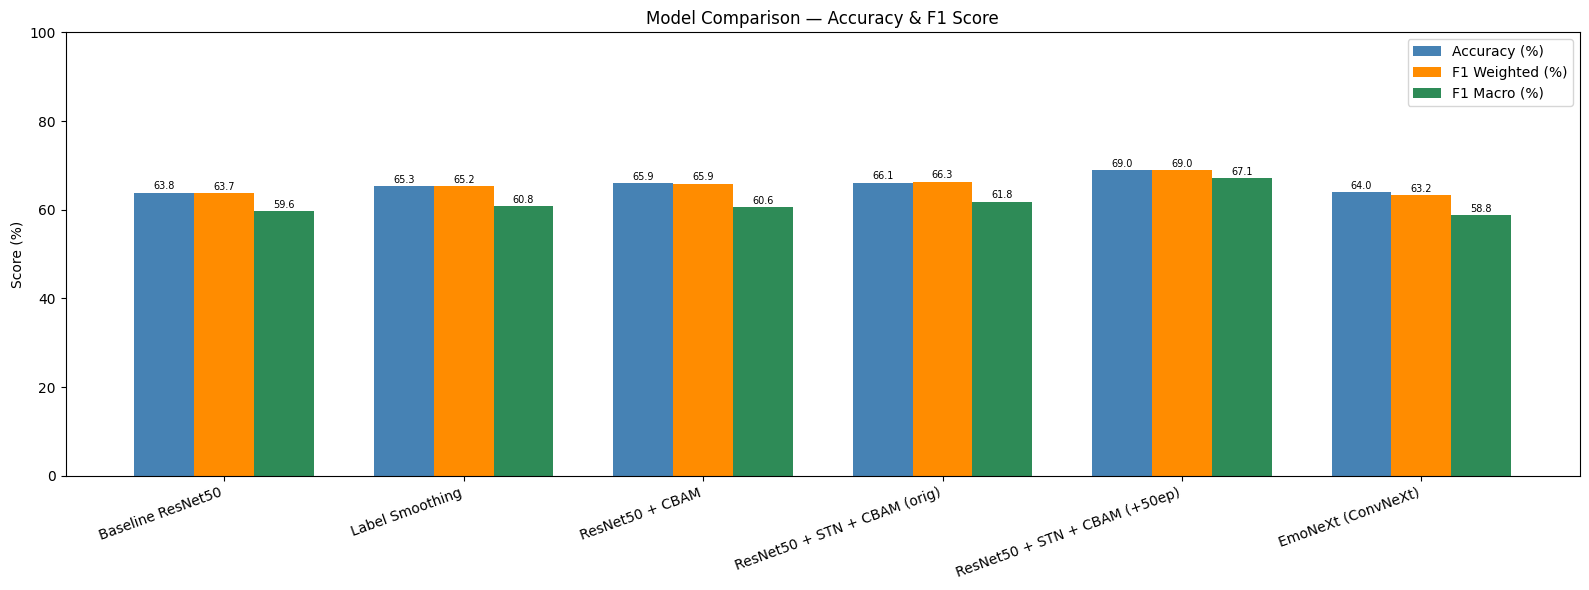


✅ Webcam bundle saved → /kaggle/working/emotion_model_webcam.pth
   Classes : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   Accuracy: 68.98%


In [2]:
# ════════════════════════════════════════════════════════════════════════
# CELL — Full Training + Evaluation + Save  (FIXED)
# Fixes applied (ported from Colab version):
#   1. STN frozen for first 10 epochs → unfrozen with lower LR + optimizer rebuild
#   2. Gradient clipping (max_norm=1.0) to prevent STN blow-up
#   3. MixUp delayed to epoch >= 20 (after STN unfreeze settles)
#   4. Initial LR lowered to 1e-4 (was 5e-4)
#   5. Checkpoint saved every epoch for crash-safe resuming
# ════════════════════════════════════════════════════════════════════════
import os
import numpy as np
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ────────────────────────────────────────────────────────────────
BATCH_SIZE        = 32
NUM_EPOCHS        = 50
LR_INITIAL        = 1e-4        # ← lowered from 5e-4
LR_AFTER_UNFREEZE = 5e-5        # ← used after STN is unfrozen at epoch 10
STN_FREEZE_EPOCHS = 10          # ← freeze STN for this many epochs
MIXUP_END_EPOCH   = 20          # ← only use MixUp before this epoch

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "/kaggle/working/"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Using device: {DEVICE}")

TRAIN_DIR = "/kaggle/input/datasets/ahmed3mk/emotion/archive (1) - Copy/train"
TEST_DIR  = "/kaggle/input/datasets/ahmed3mk/emotion/archive (1) - Copy/test"

BEST_PATH       = os.path.join(SAVE_DIR, "model4_stn_cbam_best.pth")
WEBCAM_PATH     = os.path.join(SAVE_DIR, "emotion_model_webcam.pth")
CHECKPOINT_PATH = os.path.join(SAVE_DIR, "model4_checkpoint.pth")

# ── Dataset ───────────────────────────────────────────────────────────────
class EmotionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images      = []
        self.labels      = []
        self.transform   = transform
        self.class_names = sorted(os.listdir(root_dir))
        for label, cls in enumerate(self.class_names):
            folder = os.path.join(root_dir, cls)
            if not os.path.isdir(folder):
                continue
            for img in os.listdir(folder):
                self.images.append(os.path.join(folder, img))
                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.images[idx]).convert("RGB")
        except:
            return self.__getitem__((idx + 1) % len(self.images))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ── Transforms ────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ColorJitter(0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Load Data ─────────────────────────────────────────────────────────────
full_train = EmotionDataset(TRAIN_DIR, train_transform)
val_size   = int(0.2 * len(full_train))
train_size = len(full_train) - val_size

train_dataset, val_dataset = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
test_dataset = EmotionDataset(TEST_DIR, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

num_classes = len(full_train.class_names)
class_names = full_train.class_names
print(f"Classes ({num_classes}): {class_names}")
print(f"Train: {train_size} | Val: {val_size} | Test: {len(test_dataset)}")

# ── Class Weights ─────────────────────────────────────────────────────────
counts  = Counter(full_train.labels)
total   = sum(counts.values())
weights = torch.tensor([total / counts[i] for i in range(num_classes)]).float().to(DEVICE)

# ── MixUp ─────────────────────────────────────────────────────────────────
def mixup(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(x.size(0)).to(DEVICE)
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam

# ── CBAM ──────────────────────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg  = self.fc(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_ = self.fc(self.max_pool(x).squeeze(-1).squeeze(-1))
        return x * self.sigmoid(avg + max_).unsqueeze(-1).unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg     = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.channel = ChannelAttention(in_channels)
        self.spatial = SpatialAttention()

    def forward(self, x):
        return self.spatial(self.channel(x))

# ── STN ───────────────────────────────────────────────────────────────────
class STN(nn.Module):
    def __init__(self):
        super().__init__()
        self.localization = nn.Sequential(
            nn.Conv2d(3, 8,  kernel_size=7), nn.MaxPool2d(2, stride=2), nn.ReLU(True),
            nn.Conv2d(8, 10, kernel_size=5), nn.MaxPool2d(2, stride=2), nn.ReLU(True),
        )
        # 224 → conv(7) → 218 → pool/2 → 109 → conv(5) → 105 → pool/2 → 52
        # feature map: 10 × 52 × 52 = 27040
        self.fc_loc = nn.Sequential(
            nn.Linear(10 * 52 * 52, 256), nn.ReLU(True),
            nn.Linear(256, 6)
        )
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(
            torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float)
        )

    def forward(self, x):
        xs    = self.localization(x).view(x.size(0), -1)
        theta = self.fc_loc(xs).view(-1, 2, 3)
        grid  = F.affine_grid(theta, x.size(), align_corners=False)
        return F.grid_sample(x, grid, align_corners=False)

# ── Model ─────────────────────────────────────────────────────────────────
class ResNet50WithSTNAndCBAM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stn      = STN()
        base          = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(*list(base.children())[:-2])
        self.cbam     = CBAM(2048)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.fc       = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.stn(x)
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x)
        return self.fc(x.flatten(1))

# ══════════════════════════════════════════════════════════════════════════
# Build model
# ══════════════════════════════════════════════════════════════════════════
m4 = ResNet50WithSTNAndCBAM(num_classes).to(DEVICE)

# FIX 1 — Freeze STN so backbone can learn before STN destabilises gradients
for p in m4.stn.parameters():
    p.requires_grad = False
print(f"🔒 STN frozen for first {STN_FREEZE_EPOCHS} epochs")

# FIX 4 — Lower initial LR; build optimizer with only trainable params
opt4 = optim.Adam(
    filter(lambda p: p.requires_grad, m4.parameters()),
    lr=LR_INITIAL, weight_decay=1e-4
)
sch4 = torch.optim.lr_scheduler.CosineAnnealingLR(opt4, T_max=NUM_EPOCHS)
crit = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

# ── Resume from checkpoint if it exists ───────────────────────────────────
start_epoch = 0
best_acc    = 0.0

if os.path.exists(CHECKPOINT_PATH):
    ckpt        = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    m4.load_state_dict(ckpt['model'])
    opt4.load_state_dict(ckpt['optimizer'])
    sch4.load_state_dict(ckpt['scheduler'])
    start_epoch = ckpt['epoch'] + 1
    best_acc    = ckpt['best_acc']
    # If resuming past the unfreeze point, make sure STN is unfrozen
    if start_epoch >= STN_FREEZE_EPOCHS:
        for p in m4.stn.parameters():
            p.requires_grad = True
        print(f"🔓 STN already unfrozen (resumed at epoch {start_epoch})")
    print(f"🔄 Resumed from epoch {start_epoch} | Best so far: {best_acc:.2f}%")
else:
    print("🆕 Starting fresh training")

print(f"\n{'='*55}")
print(f"🚀 Training: ResNet50 + STN + CBAM  ({NUM_EPOCHS} epochs, no early stopping)")
print(f"   STN unfreezes at epoch {STN_FREEZE_EPOCHS} | MixUp ends at epoch {MIXUP_END_EPOCH}")
print(f"{'='*55}")

for epoch in range(start_epoch, NUM_EPOCHS):

    # FIX 1 — Unfreeze STN at epoch 10, rebuild optimizer with lower LR
    if epoch == STN_FREEZE_EPOCHS:
        for p in m4.stn.parameters():
            p.requires_grad = True
        opt4 = optim.Adam(m4.parameters(), lr=LR_AFTER_UNFREEZE, weight_decay=1e-4)
        sch4 = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt4, T_max=NUM_EPOCHS - STN_FREEZE_EPOCHS
        )
        print(f"\n🔓 Epoch {epoch+1}: STN unfrozen — optimizer reset (LR={LR_AFTER_UNFREEZE})")

    # ── Train ──────────────────────────────────────────────────────────────
    m4.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt4.zero_grad()

        # FIX 3 — MixUp only before MIXUP_END_EPOCH
        if epoch < MIXUP_END_EPOCH:
            x, y_a, y_b, lam = mixup(x, y)
            out  = m4(x)
            loss = lam * crit(out, y_a) + (1 - lam) * crit(out, y_b)
        else:
            out  = m4(x)
            loss = crit(out, y)

        loss.backward()

        # FIX 2 — Gradient clipping to prevent STN parameter explosion
        torch.nn.utils.clip_grad_norm_(m4.parameters(), max_norm=1.0)

        opt4.step()
        total_loss += loss.item()

    sch4.step()

    # ── Validate ───────────────────────────────────────────────────────────
    m4.eval()
    correct, total_val = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y    = x.to(DEVICE), y.to(DEVICE)
            _, pred = torch.max(m4(x), 1)
            total_val += y.size(0)
            correct   += (pred == y).sum().item()

    val_acc    = 100 * correct / total_val
    stn_status = "🔒" if epoch < STN_FREEZE_EPOCHS else "🔓"
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} {stn_status} | Loss: {total_loss:.2f} | "
          f"Val Acc: {val_acc:.2f}% | LR: {opt4.param_groups[0]['lr']:.6f}")

    # ── Save best ──────────────────────────────────────────────────────────
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(m4.state_dict(), BEST_PATH)
        print(f"  ✅ New best saved: {best_acc:.2f}%")

    # ── Save resumable checkpoint every epoch ──────────────────────────────
    torch.save({
        'epoch'    : epoch,
        'model'    : m4.state_dict(),
        'optimizer': opt4.state_dict(),
        'scheduler': sch4.state_dict(),
        'best_acc' : best_acc,
    }, CHECKPOINT_PATH)

print(f"\n🏅 Training complete. Best val acc: {best_acc:.2f}%")

# ══════════════════════════════════════════════════════════════════════════
# Test
# ══════════════════════════════════════════════════════════════════════════
m4.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
m4.eval()

preds_list, labels_list = [], []
with torch.no_grad():
    for x, y in test_loader:
        _, p = torch.max(m4(x.to(DEVICE)), 1)
        preds_list.extend(p.cpu().numpy())
        labels_list.extend(y.numpy())

acc  = accuracy_score(labels_list, preds_list) * 100
f1_w = f1_score(labels_list, preds_list, average='weighted')
f1_m = f1_score(labels_list, preds_list, average='macro')

print(f"\n🔥 TEST ACCURACY : {acc:.2f}%")
print(f"   F1 Weighted   : {f1_w:.4f}")
print(f"   F1 Macro      : {f1_m:.4f}")
print(f"\n📊 Classification Report:")
print(classification_report(labels_list, preds_list, target_names=class_names))

cm = confusion_matrix(labels_list, preds_list)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — ResNet50 + STN + CBAM (Fixed)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "model4_confusion_matrix.png"), dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# Final Comparison Table
# ══════════════════════════════════════════════════════════════════════════
results = {
    "1. Baseline ResNet50"             : (63.83, 0.6374, 0.5963),
    "2. Label Smoothing"               : (65.29, 0.6525, 0.6077),
    "3. ResNet50 + CBAM"               : (65.93, 0.6588, 0.6063),
    "4. ResNet50 + STN + CBAM (orig)"  : (66.11, 0.6633, 0.6180),
    "4. ResNet50 + STN + CBAM (+50ep)" : (acc,   f1_w,   f1_m),
    "5. EmoNeXt (ConvNeXt)"            : (64.03, 0.6322, 0.5882),
}

names = list(results.keys())
accs  = [results[n][0]       for n in names]
f1_ws = [results[n][1] * 100 for n in names]
f1_ms = [results[n][2] * 100 for n in names]

print("\n" + "="*70)
print("                  📊 FINAL MODEL COMPARISON")
print("="*70)
print(f"{'Model':<42} {'Accuracy':>10} {'F1 Weighted':>12} {'F1 Macro':>10}")
print("-"*70)
for n, a, fw, fm in zip(names, accs, f1_ws, f1_ms):
    print(f"{n:<42} {a:>9.2f}%  {fw:>10.2f}%  {fm:>9.2f}%")
print("="*70)
best = max(results, key=lambda n: results[n][0])
print(f"\n🏆 Best Model: {best} → {results[best][0]:.2f}%")

# ── Bar Chart ─────────────────────────────────────────────────────────────
x     = np.arange(len(names))
width = 0.25
fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - width, accs,  width, label='Accuracy (%)',    color='steelblue')
b2 = ax.bar(x,         f1_ws, width, label='F1 Weighted (%)', color='darkorange')
b3 = ax.bar(x + width, f1_ms, width, label='F1 Macro (%)',    color='seagreen')
for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([n.split('. ', 1)[-1] for n in names], rotation=20, ha='right')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — Accuracy & F1 Score')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "comparison_chart_final.png"), dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# Save webcam-ready bundle
# ══════════════════════════════════════════════════════════════════════════
torch.save({
    "model_state_dict" : torch.load(BEST_PATH, map_location="cpu"),
    "class_names"      : class_names,
    "num_classes"      : num_classes,
    "architecture"     : "ResNet50WithSTNAndCBAM",
    "input_size"       : 224,
    "normalize_mean"   : [0.485, 0.456, 0.406],
    "normalize_std"    : [0.229, 0.224, 0.225],
    "test_accuracy"    : acc,
    "f1_weighted"      : f1_w,
    "f1_macro"         : f1_m,
}, WEBCAM_PATH)

print(f"\n✅ Webcam bundle saved → {WEBCAM_PATH}")
print(f"   Classes : {class_names}")
print(f"   Accuracy: {acc:.2f}%")

del m4, opt4, sch4
torch.cuda.empty_cache()


In [3]:
# ── Verify saved files ─────────────────────────────────────────────────────
import os

print("📁 Files in /kaggle/working/:")
for f in sorted(os.listdir("/kaggle/working/")):
    size_mb = os.path.getsize(f"/kaggle/working/{f}") / (1024 * 1024)
    print(f"  {f}  ({size_mb:.1f} MB)")

📁 Files in /kaggle/working/:
  __notebook__.ipynb  (0.2 MB)
  comparison_chart_final.png  (0.1 MB)
  emotion_model_webcam.pth  (118.5 MB)
  model4_checkpoint.pth  (355.0 MB)
  model4_confusion_matrix.png  (0.1 MB)
  model4_stn_cbam_best.pth  (118.5 MB)


In [4]:
import os
# List all .pth files saved in working dir
pth_files = [f for f in os.listdir("/kaggle/working/") if f.endswith(".pth")]
print("Found .pth files:")
for f in pth_files:
    print(f"  {f}")

Found .pth files:
  emotion_model_webcam.pth
  model4_checkpoint.pth
  model4_stn_cbam_best.pth
